In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/dell/ML-Learning/datasets/online_retail_II_cleaned.csv")

In [2]:
print(df.shape)
df.info()
df.head()

(1021452, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1021452 entries, 0 to 1021451
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   invoice          1021452 non-null  str    
 1   stockcode        1021452 non-null  str    
 2   description      1021452 non-null  str    
 3   quantity         1021452 non-null  int64  
 4   invoicedate      1021452 non-null  str    
 5   price            1021452 non-null  float64
 6   customer_id      794186 non-null   float64
 7   country          1021452 non-null  str    
 8   is_cancelled     1021452 non-null  bool   
 9   has_customer_id  1021452 non-null  bool   
dtypes: bool(2), float64(2), int64(1), str(5)
memory usage: 64.3 MB


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,has_customer_id
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,True


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df = numeric_df.drop(columns=["customer_id"])
numeric_df.head()

,quantity,price
0,12,6.95
1,12,6.75
2,12,6.75
3,48,2.10
4,24,1.25


In [5]:
cov_matrix = numeric_df.cov()
print(cov_matrix)
corr_matrix = numeric_df.corr()
print(corr_matrix)

              quantity      price
quantity  28582.515323 -16.823557
price       -16.823557  23.274310
          quantity     price
quantity  1.000000 -0.020627
price    -0.020627  1.000000


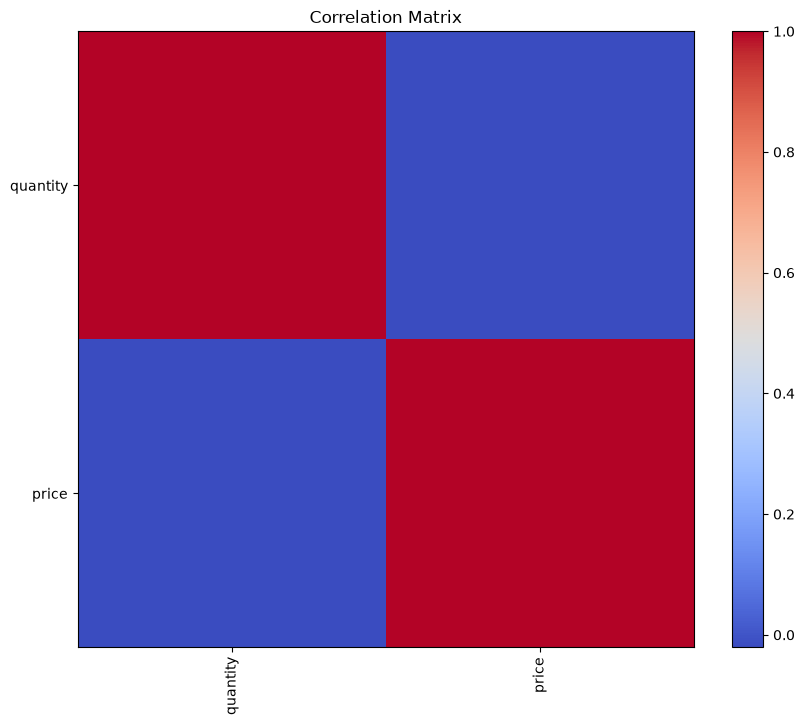

In [6]:
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

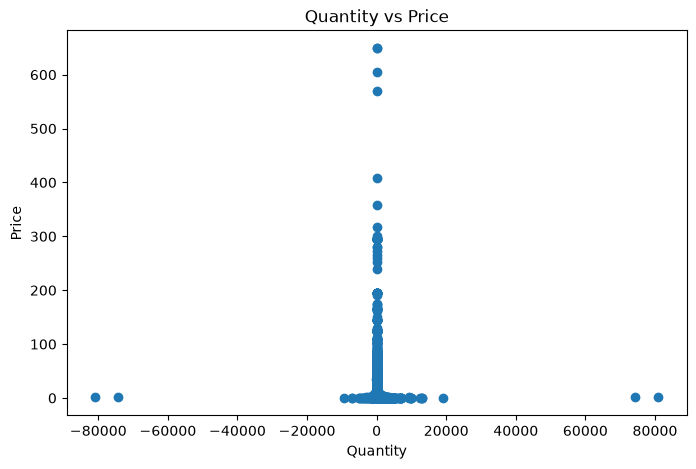

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["quantity"], df["price"])
plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Quantity vs Price")
plt.show()

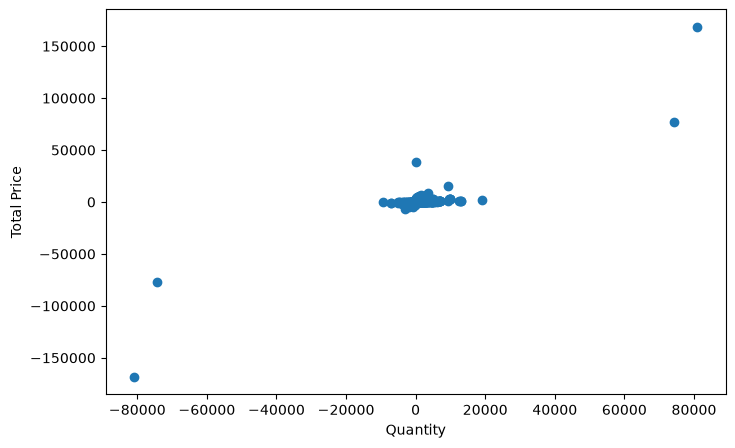

In [8]:
df["total_price"] = df["quantity"] * df["price"]

plt.figure(figsize=(8,5))
plt.scatter(df["quantity"], df["total_price"])
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

### Observations

- Quantity and Total Price have a positive correlation, which means higher quantities generally result in higher total prices.
- Price and Quantity show only a weak relationship.
- Correlation values closer to 1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship.
- The `customer_id` column was excluded because it is only used to identify customers and does not provide meaningful information for correlation analysis.
